# Module 3 Homework - Seaborn
Using a dataset about Pokemon combat statistic, we will practice data visualization using the seaborn library.  
<img src="https://cdn.arstechnica.net/wp-content/uploads/2020/07/pokemon-go-masks-800x450.jpg">

In this notebook, we will plot the relationships between different observations of the combat statistics of Pokémon. You will need to import a few packages, including `pandas`, `matplotlib.pyplot`, and `seaborn`. The data is stored in a csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Here are the descriptions of this dataset:
- `#` - Pokedex entry number of the Pokemon
- `Name` - name of the Pokemon
- `Type 1` - each Pokemon has a type, this determines weakness/resistance to attacks [referred to as the primary type]
- `Type 2` - some Pokemon are dual type and have 2 [referred to as the secondary type]
- `Total` - sum of all stats that come after this, a general guide to how strong a Pokemon is
- `HP` - hit points, or health, defines how much damage a Pokemon can withstand before fainting
- `Attack` - the base modifier for normal attacks
- `Defense` - the base damage resistance against normal attacks
- `Sp. Atk` - special attack, the base modifier for special attacks
- `Sp. Def` - the base damage resistance against special attacks
- `Speed` - determines which Pokemon attacks first each round
- `Generation` - refers to which grouping/game series the Pokemon was released in
- `Legendary` - a boolean that identifies whether the Pokemon is legendary

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fp = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv"

## Q1: Plot the relationship between Attack and Defense
Create a relationship plot using seaborn's `relplot` function. Plot `Attack` on the x-axis and `Defense` on the y-axis. Use `hue` to display the `HP` (hit point) for each datapoint. You can choose your favorite palette. Include a meaninful title in the plot. After creating the plot, insert a markdown cell :immediately following the plot to describe the relationship between Attack and Defense in this dataset.

### From the plot, I observed....
Results: There is a positive correlation between `Attack` and `Defense`. The hit-points (`HP`) is higher for Pokemons with higher `Attack` and `Defense` values.

The dots mostly go up as you go right, which means Pokémon with higher Attack usually also have higher Defense (a positive relationship).

Most Pokémon are clustered in the middle (around Attack 40–100 and Defense 40–100), so that’s where the “typical” Pokémon stats are.


A few Pokémon are far away from the main cluster (outliers), meaning they have unusually high Attack or Defense compared to most Pokémon.

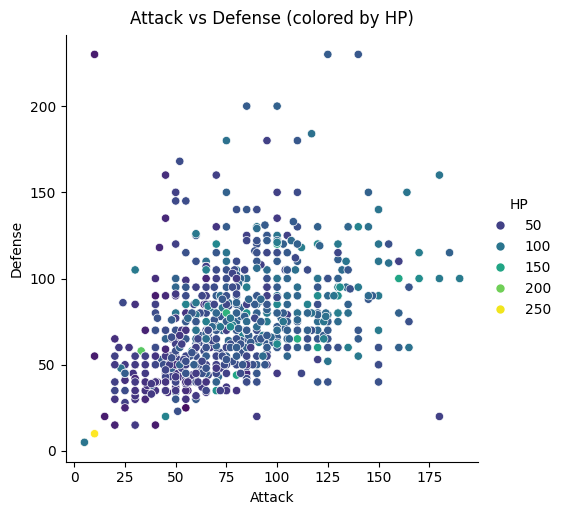

In [2]:

pokemon = pd.read_csv(fp)

# Make a scatter plot that shows Attack vs Defense
g = sns.relplot(
    data=pokemon,        # the table we’re using
    x="Attack",          # column for x-axis
    y="Defense",         # column for y-axis
    hue="HP",            # color points based on HP values
    palette="viridis"    # color style
)

# Title
g.fig.suptitle("Attack vs Defense (colored by HP)", y=1.02)
plt.show()

## Q2: Plot the relationship between Attack and Total using a hexbin plot
Create a hexbin plot using seaborn's `joinplot` function. Plot `Attack` on the x-axis and `Total` on the y-axis. You can choose the gridsize. Include a title for the plot "Attack vs total for all Pokemon". After generating the plot, insert a markdown cell to answer this question: The hexbin plot displays the relationship between `Attack` and `Total`, what else does this plot show?

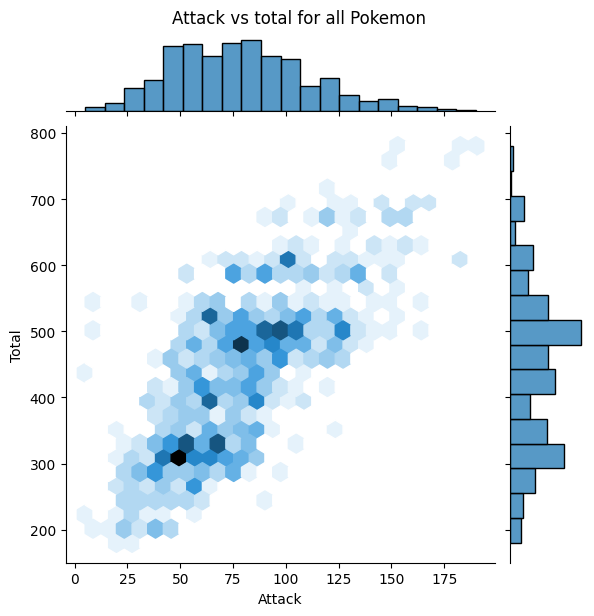

In [3]:
g = sns.jointplot(
    data=pokemon,
    x="Attack",
    y="Total",
    kind="hex",      # hexbin plot
    gridsize=25      # size of the hexagon grid (you can change this)
)

g.fig.suptitle("Attack vs total for all Pokemon", y=1.02)
plt.show()

From the plot, I observed....

1. The plot shows a clear upward trend, meaning higher Attack usually comes with higher Total stats.

2. Most Pokémon are concentrated around Attack ~50–100 and Total ~300–500.

3. This plot also shows extra information on the sides:

4. The top histogram shows the distribution of Attack (most Attack values are in the middle).

5. The right histogram shows the distribution of Total (most Totals are also in the middle).

6. There are some high-stat outliers (high Total and high Attack), but they are rare.




## Q3: Create two categorical plots for Pokemon types. `Type 1` and `Type 2` .
For each plot, the unique values of `Type 1` or `Type 2` should be plotted along the y-axis, and the counts of Pokemon should be on the x-axis. Use the color red for the `Type 1` plot and blue for the `Type 2` plot. After the two plots are displayed, insert a markdown cell to write your findings: Which are the most common `Type 1` and `Type 2` Pokemons, and which are the most rare ones?

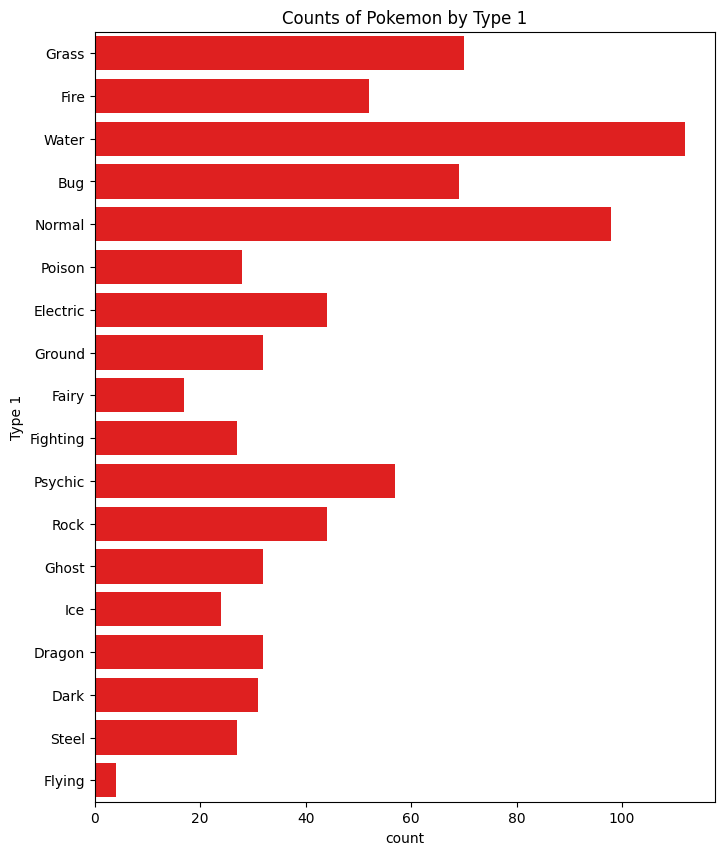

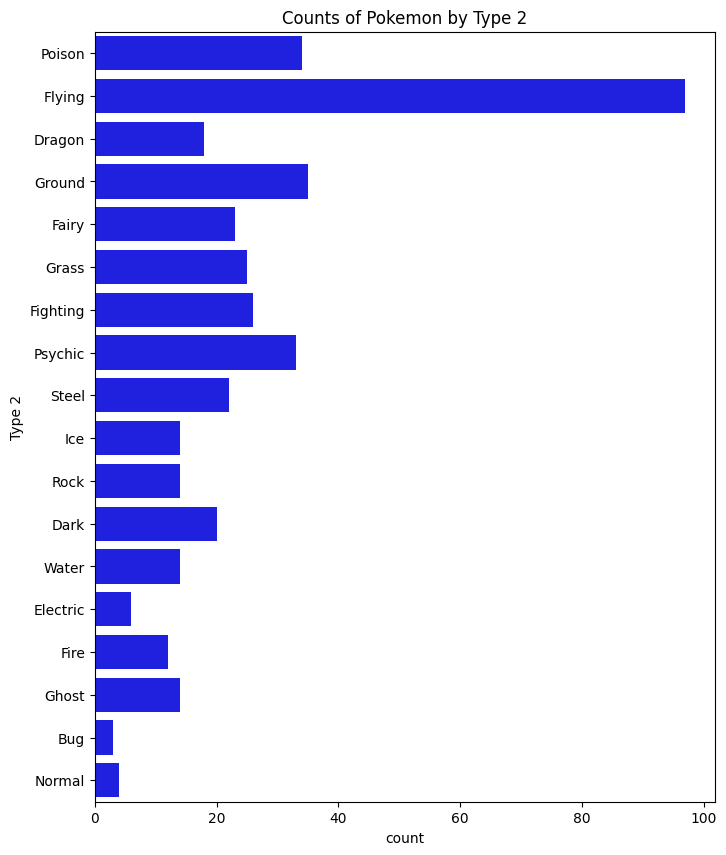

In [4]:
plt.figure(figsize=(8, 10))
sns.countplot(data=pokemon, y="Type 1", color="red")
plt.title("Counts of Pokemon by Type 1")
plt.show()

plt.figure(figsize=(8, 10))
sns.countplot(data=pokemon, y="Type 2", color="blue")
plt.title("Counts of Pokemon by Type 2")
plt.show()

## Q4-6: Your own question
Come up with three more questions to further explore the pokemon dataset.



```
# This is formatted as code
```

### **Q4: Do Legendary Pokémon have higher Total stats than non-Legendary?**

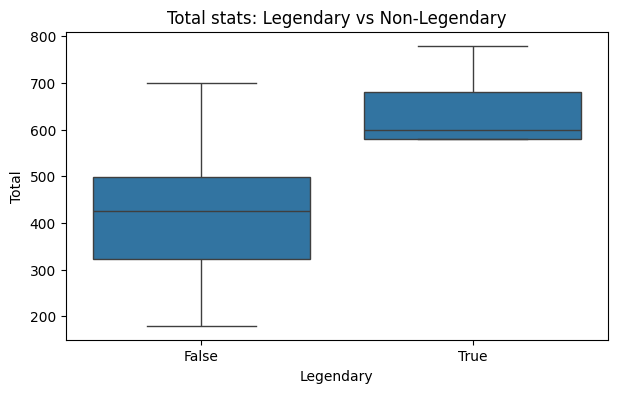

In [5]:
# Q4: Legendary vs Total (box plot)
plt.figure(figsize=(7, 4))
sns.boxplot(data=pokemon, x="Legendary", y="Total")
plt.title("Total stats: Legendary vs Non-Legendary")
plt.show()

### **Q5: Which Type 1 has the highest average Attack?**

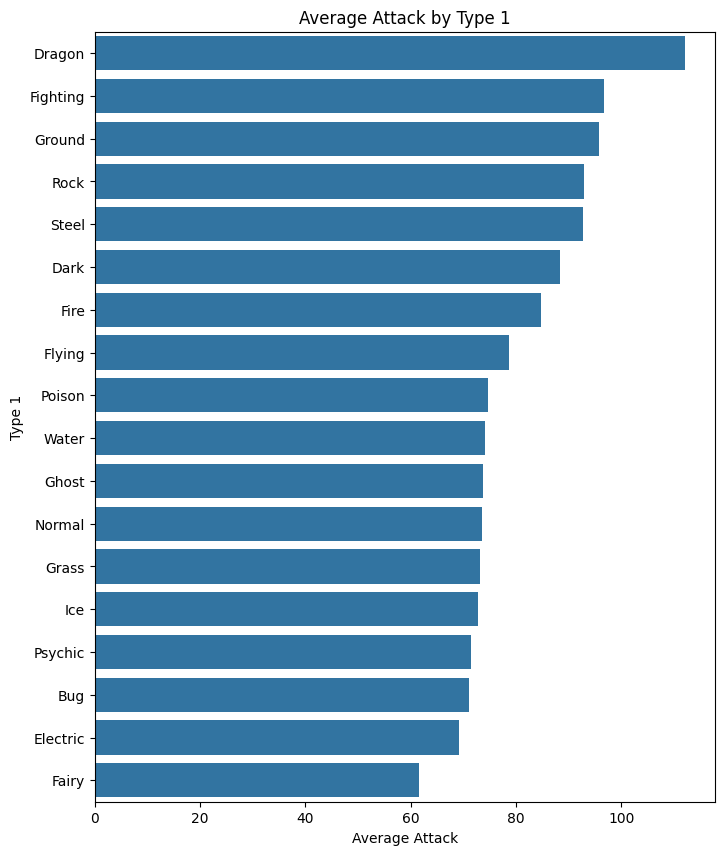

In [6]:
# Q5: Average Attack by Type 1 (bar plot)
avg_attack = pokemon.groupby("Type 1")["Attack"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=avg_attack.values, y=avg_attack.index)
plt.title("Average Attack by Type 1")
plt.xlabel("Average Attack")
plt.ylabel("Type 1")
plt.show()

## Q6: What is the relationship between Speed and Total, and does Legendary status change it?


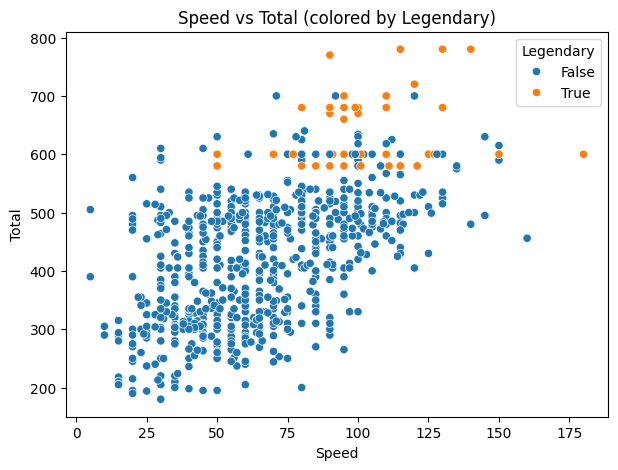

In [7]:
# Q6: Speed vs Total, colored by Legendary (scatter plot)
plt.figure(figsize=(7, 5))
sns.scatterplot(data=pokemon, x="Speed", y="Total", hue="Legendary")
plt.title("Speed vs Total (colored by Legendary)")
plt.show()